# Analyse des Trigger Words — Exam 12
Objectif : identifier les mots qui sont **statistiquement associés aux bonnes réponses** (et aux mauvaises) parmi les choix du QCM.

**Approche** :
1. Construire deux corpus : texte des **choix corrects** vs texte des **choix incorrects**
2. Calculer TF-IDF + log-odds ratio pour chaque mot
3. Visualiser les top trigger words positifs / négatifs
4. Valider avec un test statistique (chi²)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = "../data/processed/questions_exam12_ready_fix.csv"
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f"Shape: {df.shape}")
df.head(2)

Shape: (319, 16)


,question_id,topic,question_text,choice_A,choice_B,choice_C,choice_D,choice_E,choice_F,answer,question_type,nb_choices,nb_comments,url,page,explanation
0,1,1,Your company built a TensorFlow neutral-networ...,Threading,Serialization,Dropout Methods,Dimensionality Reduction,NaN,NaN,C,single,4,25,https://www.examtopics.com/discussions/google/...,1,La méthode correcte pour améliorer les perform...
1,2,1,Your company is in a highly regulated industry...,Disable writes to certain tables.,Restrict access to tables by role.,Ensure that the data is encrypted at all times.,Restrict BigQuery API access to approved users.,Segregate data across multiple tables or datab...,Use Google Stackdriver Audit Logging to determ...,B|D|E,multiple,6,43,https://www.examtopics.com/discussions/google/...,1,"Les réponses correctes sont B, D et E. \n\nB. ..."


## 1. Préparation — Séparer choix corrects vs incorrects

In [2]:
CHOICE_COLS = ['choice_A', 'choice_B', 'choice_C', 'choice_D', 'choice_E', 'choice_F']
LETTERS = ['A', 'B', 'C', 'D', 'E', 'F']

correct_texts = []
wrong_texts = []

for _, row in df.iterrows():
    correct_set = set(row['answer'].split('|'))
    for letter, col in zip(LETTERS, CHOICE_COLS):
        text = str(row[col]).strip()
        if text in ('', 'nan'):
            continue
        if letter in correct_set:
            correct_texts.append(text)
        else:
            wrong_texts.append(text)

print(f"Choix corrects  : {len(correct_texts)}")
print(f"Choix incorrects: {len(wrong_texts)}")
print(f"\nExemples corrects : {correct_texts[:5]}")
print(f"Exemples incorrects: {wrong_texts[:5]}")

Choix corrects  : 340
Choix incorrects: 963

Exemples corrects : ['Dropout Methods', 'Restrict access to tables by role.', 'Restrict BigQuery API access to approved users.', 'Segregate data across multiple tables or databases.', 'Use a Cloud Dataflow pipeline to stream data into the BigQuery table.']
Exemples incorrects: ['Threading', 'Serialization', 'Dimensionality Reduction', 'Disable writes to certain tables.', 'Ensure that the data is encrypted at all times.']


## 2. Tokenisation et fréquences

In [3]:
import re

# Stopwords anglais simples (sans NLTK download)
STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'by','from','is','are','be','been','was','were','it','its','this','that',
    'which','as','use','using','your','you','they','their','all','each',
    'into','have','has','will','can','not','no','do','does','used','new',
    'via','per','than','when','if','up','out','set','get','both','more',
    'allow','allows','s','only','so','within','between','across','through',
    'google','cloud','gcp','data', 'based'
}

def tokenize(texts):
    tokens = []
    for t in texts:
        words = re.findall(r"[a-zA-Z][a-zA-Z\-]{1,}", t.lower())
        tokens.extend([w for w in words if w not in STOPWORDS and len(w) > 2])
    return tokens

correct_tokens = tokenize(correct_texts)
wrong_tokens   = tokenize(wrong_texts)

correct_freq = Counter(correct_tokens)
wrong_freq   = Counter(wrong_tokens)

print(f"Tokens corrects  : {len(correct_tokens)} ({len(correct_freq)} uniques)")
print(f"Tokens incorrects: {len(wrong_tokens)} ({len(wrong_freq)} uniques)")
print("\nTop 10 corrects:", correct_freq.most_common(10))
print("Top 10 incorrects:", wrong_freq.most_common(10))

Tokens corrects  : 3331 (1201 uniques)
Tokens incorrects: 9656 (1804 uniques)

Top 10 corrects: [('bigquery', 93), ('create', 90), ('table', 67), ('storage', 67), ('dataflow', 42), ('bucket', 29), ('pub', 28), ('sub', 28), ('dataset', 25), ('access', 23)]
Top 10 incorrects: [('bigquery', 296), ('create', 264), ('storage', 194), ('table', 149), ('dataflow', 111), ('job', 77), ('cluster', 72), ('write', 72), ('tables', 67), ('pub', 67)]


## 3. Log-Odds Ratio — score de "trigger"
> Un log-odds élevé = le mot apparaît beaucoup plus dans les bonnes réponses que dans les mauvaises.

In [4]:
N_correct = len(correct_tokens)
N_wrong   = len(wrong_tokens)

# Vocabulaire commun (apparaît au moins 3 fois au total)
all_words = set(correct_freq.keys()) | set(wrong_freq.keys())
vocab = [w for w in all_words if (correct_freq[w] + wrong_freq[w]) >= 3]
print(f"Vocabulaire filtré (≥3 occurrences): {len(vocab)} mots")

records = []
for w in vocab:
    c = correct_freq[w]
    k = wrong_freq[w]
    # log-odds with Laplace smoothing (+0.5)
    p_correct = (c + 0.5) / (N_correct + 1)
    p_wrong   = (k + 0.5) / (N_wrong   + 1)
    log_odds  = np.log(p_correct / (1 - p_correct)) - np.log(p_wrong / (1 - p_wrong))
    # chi2 test
    contingency = [[c, N_correct - c], [k, N_wrong - k]]
    chi2, pval, _, _ = chi2_contingency(contingency, correction=False)
    records.append({
        'word': w,
        'count_correct': c,
        'count_wrong': k,
        'pct_correct': round(100 * c / N_correct, 2),
        'pct_wrong':   round(100 * k / N_wrong, 2),
        'log_odds': round(log_odds, 3),
        'chi2': round(chi2, 3),
        'pval': round(pval, 4),
    })

stats = pd.DataFrame(records).sort_values('log_odds', ascending=False)
stats['significant'] = stats['pval'] < 0.05
print(f"\nMots significatifs (p<0.05): {stats['significant'].sum()}")
stats.head(10)

Vocabulaire filtré (≥3 occurrences): 951 mots



Mots significatifs (p<0.05): 25


,word,count_correct,count_wrong,pct_correct,pct_wrong,log_odds,chi2,pval,significant
39,format-preserving,3,0,0.09,0.00,3.011,8.698,0.0032,True
304,drain,3,0,0.09,0.00,3.011,8.698,0.0032,True
822,rdb,3,0,0.09,0.00,3.011,8.698,0.0032,True
747,most,4,1,0.12,0.01,2.164,7.748,0.0054,True
402,max,3,1,0.09,0.01,1.912,5.110,0.0238,True
206,turbo,3,1,0.09,0.01,1.912,5.110,0.0238,True
537,control,3,1,0.09,0.01,1.912,5.110,0.0238,True
381,direct,3,1,0.09,0.01,1.912,5.110,0.0238,True
843,introduce,3,1,0.09,0.01,1.912,5.110,0.0238,True
133,range,5,2,0.15,0.02,1.854,7.697,0.0055,True


## 4. Visualisation — Top trigger words

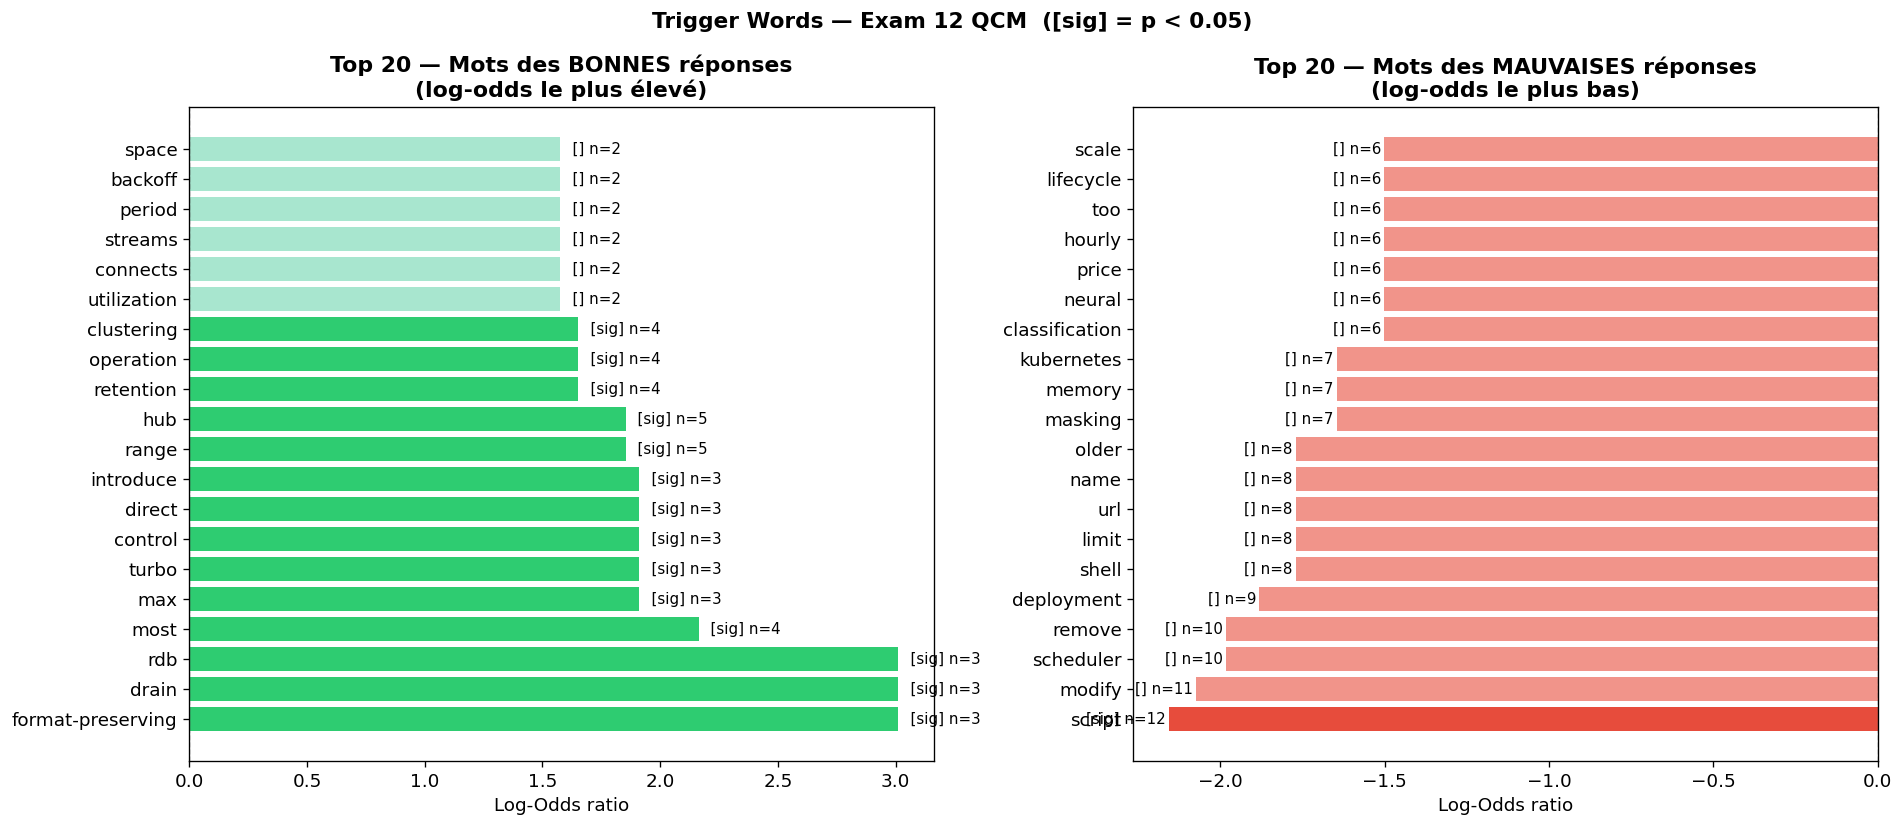

Saved: trigger_words_bar.png


In [5]:
TOP_N = 20

top_correct = stats.head(TOP_N)
top_wrong   = stats.tail(TOP_N).sort_values('log_odds')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -- Trigger positifs (favorisent bonne réponse) --
colors_pos = ['#2ecc71' if sig else '#a8e6cf' for sig in top_correct['significant']]
axes[0].barh(top_correct['word'], top_correct['log_odds'], color=colors_pos)
axes[0].set_title('Top 20 — Mots des BONNES réponses\n(log-odds le plus élevé)', fontweight='bold')
axes[0].set_xlabel('Log-Odds ratio')
axes[0].axvline(0, color='grey', linestyle='--', linewidth=0.8)
for i, (_, row) in enumerate(top_correct.iterrows()):
    marker = 'sig' if row['significant'] else ''
    axes[0].text(row['log_odds'] + 0.01, i, f"  [{marker}] n={row['count_correct']}", va='center', fontsize=9)

# -- Trigger négatifs (favorisent mauvaise réponse) --
colors_neg = ['#e74c3c' if sig else '#f1948a' for sig in top_wrong['significant']]
axes[1].barh(top_wrong['word'], top_wrong['log_odds'], color=colors_neg)
axes[1].set_title('Top 20 — Mots des MAUVAISES réponses\n(log-odds le plus bas)', fontweight='bold')
axes[1].set_xlabel('Log-Odds ratio')
axes[1].axvline(0, color='grey', linestyle='--', linewidth=0.8)
for i, (_, row) in enumerate(top_wrong.iterrows()):
    marker = 'sig' if row['significant'] else ''
    axes[1].text(row['log_odds'] - 0.01, i, f"[{marker}] n={row['count_wrong']}", va='center', ha='right', fontsize=9)

plt.suptitle('Trigger Words — Exam 12 QCM  ([sig] = p < 0.05)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('trigger_words_bar.png', bbox_inches='tight')
plt.show()
print("Saved: trigger_words_bar.png")

## 5. Word Cloud — Correct vs Incorrect

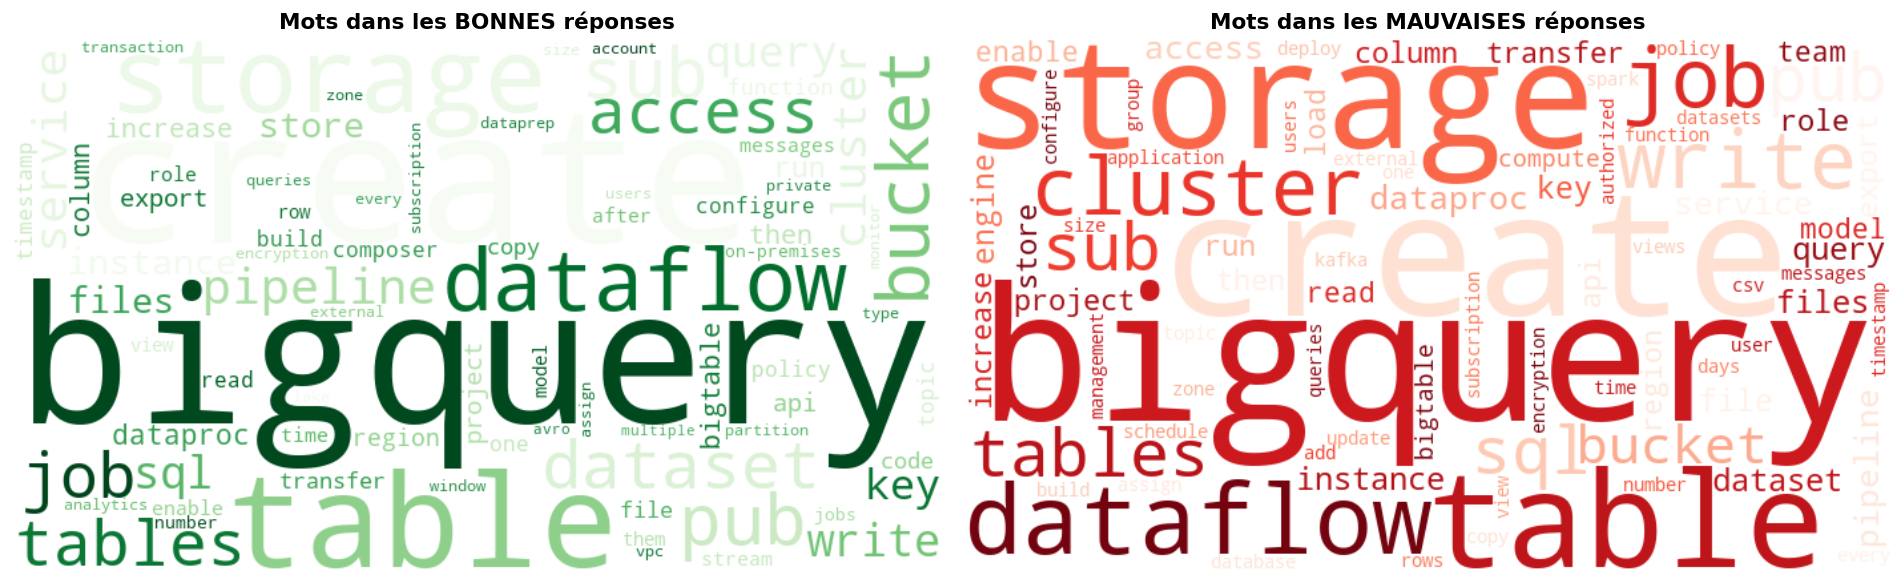

Saved: wordclouds.png


In [6]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_correct = WordCloud(width=700, height=400, background_color='white',
                       colormap='Greens', max_words=80)
wc_correct.generate_from_frequencies(correct_freq)
axes[0].imshow(wc_correct, interpolation='bilinear')
axes[0].set_title('Mots dans les BONNES réponses', fontweight='bold', fontsize=13)
axes[0].axis('off')

wc_wrong = WordCloud(width=700, height=400, background_color='white',
                     colormap='Reds', max_words=80)
wc_wrong.generate_from_frequencies(wrong_freq)
axes[1].imshow(wc_wrong, interpolation='bilinear')
axes[1].set_title('Mots dans les MAUVAISES réponses', fontweight='bold', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()
print("Saved: wordclouds.png")

## 6. Scatter — Fréquence vs Log-Odds (vue d'ensemble)

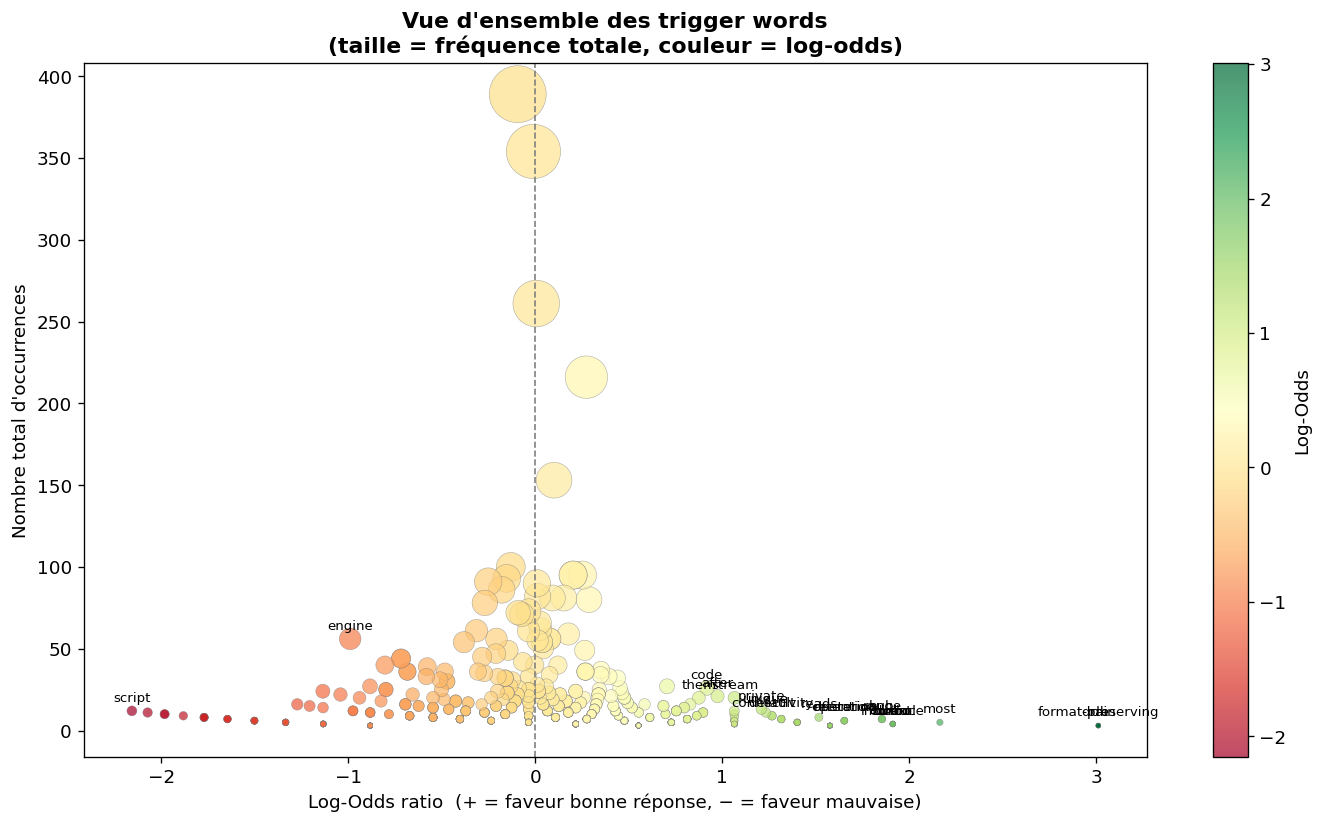

Saved: trigger_scatter.png


In [7]:
stats['total_count'] = stats['count_correct'] + stats['count_wrong']

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    stats['log_odds'],
    stats['total_count'],
    c=stats['log_odds'],
    cmap='RdYlGn',
    alpha=0.7,
    s=stats['total_count'] * 3,
    edgecolors='grey',
    linewidths=0.3
)

# Annoter les mots significatifs avec log_odds fort
to_label = stats[(stats['significant']) & (stats['log_odds'].abs() > 0.3)]
for _, row in to_label.iterrows():
    ax.annotate(row['word'], (row['log_odds'], row['total_count']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

ax.axvline(0, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Log-Odds ratio  (+ = faveur bonne réponse, − = faveur mauvaise)')
ax.set_ylabel('Nombre total d\'occurrences')
ax.set_title('Vue d\'ensemble des trigger words\n(taille = fréquence totale, couleur = log-odds)', fontweight='bold')
plt.colorbar(sc, label='Log-Odds')
plt.tight_layout()
plt.savefig('trigger_scatter.png', bbox_inches='tight')
plt.show()
print("Saved: trigger_scatter.png")

## 7. Export — Table complète des trigger words significatifs

In [8]:
sig_stats = stats[stats['significant']].copy()
sig_stats['direction'] = sig_stats['log_odds'].apply(lambda x: 'BONNE reponse' if x > 0 else 'MAUVAISE reponse')
sig_stats = sig_stats[['word', 'direction', 'log_odds', 'count_correct', 'count_wrong',
                        'pct_correct', 'pct_wrong', 'chi2', 'pval']].reset_index(drop=True)

out_path = 'trigger_words_significant.csv'
sig_stats.to_csv(out_path, index=False)
print(f"Exporté: {out_path}  ({len(sig_stats)} mots)\n")

print("=== Top 15 BONNE réponse ===")
print(sig_stats[sig_stats['direction']=='BONNE reponse'].head(15).to_string(index=False))
print("\n=== Top 15 MAUVAISE réponse ===")
print(sig_stats[sig_stats['direction']=='MAUVAISE reponse'].tail(15).to_string(index=False))

Exporté: trigger_words_significant.csv  (25 mots)

=== Top 15 BONNE réponse ===
             word     direction  log_odds  count_correct  count_wrong  pct_correct  pct_wrong  chi2   pval
format-preserving BONNE reponse     3.011              3            0         0.09       0.00 8.698 0.0032
            drain BONNE reponse     3.011              3            0         0.09       0.00 8.698 0.0032
              rdb BONNE reponse     3.011              3            0         0.09       0.00 8.698 0.0032
             most BONNE reponse     2.164              4            1         0.12       0.01 7.748 0.0054
              max BONNE reponse     1.912              3            1         0.09       0.01 5.110 0.0238
            turbo BONNE reponse     1.912              3            1         0.09       0.01 5.110 0.0238
          control BONNE reponse     1.912              3            1         0.09       0.01 5.110 0.0238
           direct BONNE reponse     1.912              3        

## 8. Analyse d'un mot spécifique

In [ ]:
import re

# ── Mot à analyser ────────────────────────────────────────────────────────────
WORD = "write"

# ── 1. Stats depuis le DataFrame stats ───────────────────────────────────────
row = stats[stats['word'] == WORD]

if row.empty:
    c = correct_freq.get(WORD, 0)
    k = wrong_freq.get(WORD, 0)
    print(f"⚠️  '{WORD}' absent du vocabulaire filtré (< 3 occurrences au total)")
    print(f"   Dans corrects  : {c}")
    print(f"   Dans incorrects: {k}")
else:
    r = row.iloc[0]
    total = r['count_correct'] + r['count_wrong']
    rate = r['count_correct'] / total * 100

    print(f"{'═'*50}")
    print(f"  Mot analysé       : '{WORD}'")
    print(f"{'═'*50}")
    print(f"  Occurrences totales      : {int(total)}")
    print(f"  Dans bonnes réponses     : {int(r['count_correct'])}  ({r['pct_correct']}% des tokens corrects)")
    print(f"  Dans mauvaises réponses  : {int(r['count_wrong'])}  ({r['pct_wrong']}% des tokens incorrects)")
    print(f"  % occurrences dans bons  : {rate:.1f}%")
    print(f"{'─'*50}")
    direction = "→ favorise BONNE réponse" if r['log_odds'] > 0 else "→ favorise MAUVAISE réponse"
    print(f"  Log-Odds         : {r['log_odds']:+.3f}  {direction}")
    print(f"  Chi²             : {r['chi2']}")
    print(f"  p-value          : {r['pval']}")
    print(f"  Significatif     : {'✓ oui (p < 0.05)' if r['significant'] else '✗ non'}")

# ── 2. Choix bruts contenant le mot ──────────────────────────────────────────
pattern = re.compile(r'\b' + re.escape(WORD) + r'\b', re.IGNORECASE)

matches_correct = [t for t in correct_texts if pattern.search(t)]
matches_wrong   = [t for t in wrong_texts   if pattern.search(t)]

print(f"\n{'─'*50}")
print(f"  Choix CORRECTS contenant '{WORD}' ({len(matches_correct)}) :")
for t in matches_correct:
    print(f"    ✓  {t}")

print(f"\n  Choix INCORRECTS contenant '{WORD}' ({len(matches_wrong)}) :")
for t in matches_wrong[:15]:
    print(f"    ✗  {t}")
if len(matches_wrong) > 15:
    print(f"    … et {len(matches_wrong) - 15} autres")